# 97953.09620956126 1.846372364689991 0.27080128015453203
Rcrit (Max to have res) 27.0801280154532
Fr =  97953.09620956126
m = 0.003692744729379982
f0 = 97953.09620956126
fd = 97952.42834526484
Max current A 10.573631664573997


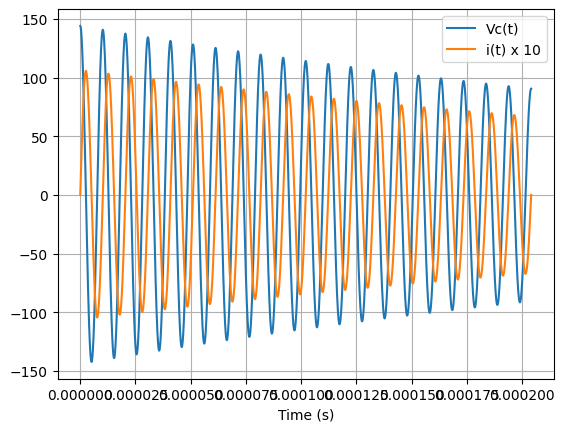

In [1]:
# RES

from math import *
L= 22e-6
C=120e-9
F=1/(2*pi*sqrt(L*C))
R=50
m = (R/2)*sqrt(C/L)
Q=1/(2*m)
print("#", F, m, Q)
# 97953.09620956126 1.846372364689991 0.270801280154

import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

L = 22e-6#+82e-6
C = 120e-9
Rcrit = 2*np.sqrt(L/C)
F=1/(2*pi*sqrt(L*C))
print("Rcrit (Max to have res)",Rcrit)
print("Fr = ", F)

R = 0.1    # <-- MUST be < 27 ohm
V0 = 48*3

w0 = 1/np.sqrt(L*C)
m = (R/2)*np.sqrt(C/L)

alpha = w0*m
wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

print("m =", m)
print("f0 =", w0/(2*np.pi))
print("fd =", wd/(2*np.pi))

def vc(t):
    return V0*np.exp(-alpha*t)*(
        np.cos(wd*t) + (alpha/wd)*np.sin(wd*t)
    )

def i(t):
    return (V0/(L*wd))*np.exp(-alpha*t)*np.sin(wd*t)

t = np.linspace(0, 20*(2*np.pi/wd), 2000)

plt.figure()
plt.plot(t, vc(t), label="Vc(t)")
plt.plot(t, 10*i(t), label="i(t) x 10")
print("Max current A", i(t).max())
plt.xlabel("Time (s)")
plt.grid(True)
plt.legend()
plt.show()


# Current sensor

In [25]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

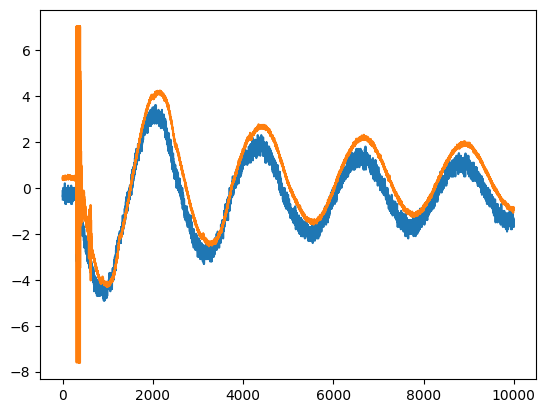

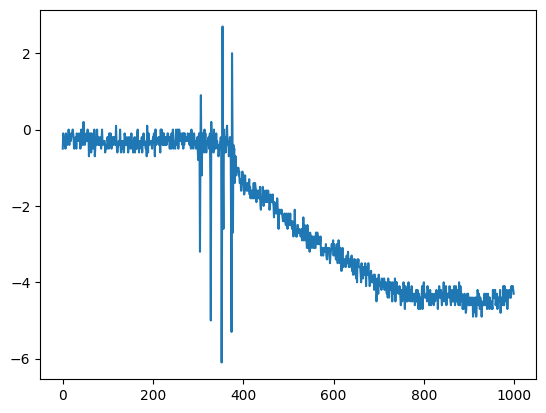

In [26]:
import pandas as pd
df = pd.read_csv("2026-01-12_17-47-35-714.csv")
I = df.CH2.values
v= -df.CH3.values
R = 0.007
plt.plot(I)
plt.plot(v/R)
plt.show()
plt.plot(I[:1000 ])
Ts= df.Ts.iloc[0]
time  =np.arange(0, len(I)*Ts, Ts)


Text(0.5, 0, 'time µs')

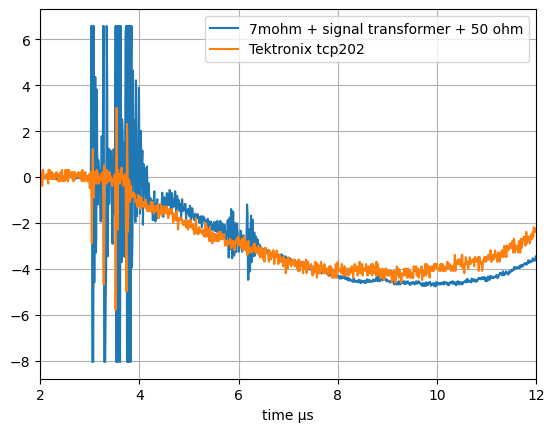

In [32]:
from copy import copy 

ir_ = copy(v/R)
is_= copy(I)
ir_ = ir_ - ir_[:200].mean()
is_ = is_ - is_[:200].mean()
plt.plot(time*1e6, ir_, label = "7mohm + signal transformer + 50 ohm")
plt.plot(time*1e6, is_, label = "Tektronix tcp202")
plt.legend()
plt.grid()
plt.xlim([2,12])
plt.xlabel("time µs")

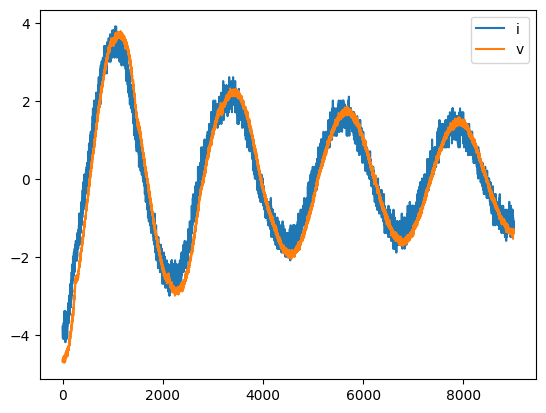

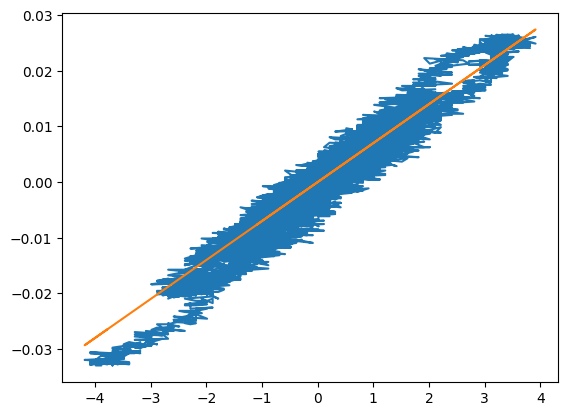

In [21]:
I = I-I[:200].mean()
v= v-v[:200].mean()
I = I[1000:]
v = v[1000:]
plt.show()
plt.plot(I, label = "i")
plt.plot(v/R, label = "v")
plt.legend()
plt.show()

plt.plot(I,v)
plt.plot(I,I*R)

In [22]:
time  =np.arange(0, len(I)*Ts, Ts)

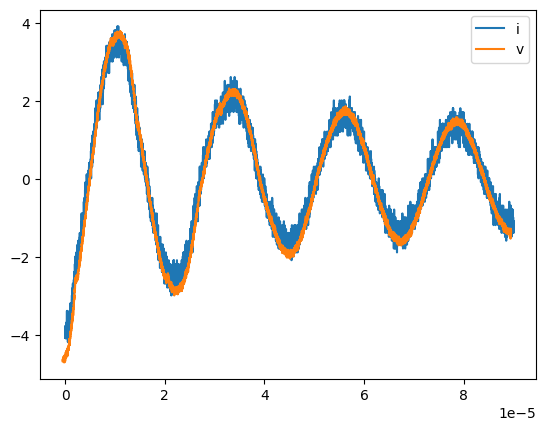

n =  50


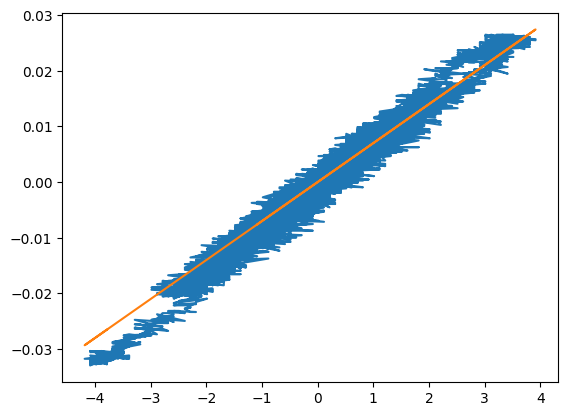

In [23]:
dt = 0.5e-6
plt.plot(time, I, label = "i")
plt.plot(time-dt , v/R, label = "v")
plt.legend()
plt.show()


n= int(dt/Ts)
print("n = ", n)

plt.plot(I[:-n//2],v[n//2:])
plt.plot(I,I*R)


In [103]:
import numpy as np
from scipy import signal

fs = 1 / Ts          # sampling frequency
fc = 5e6          # cutoff frequency (Hz)
order = 4

# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')

# zero-phase filtering
I2= signal.sosfiltfilt(sos, I)

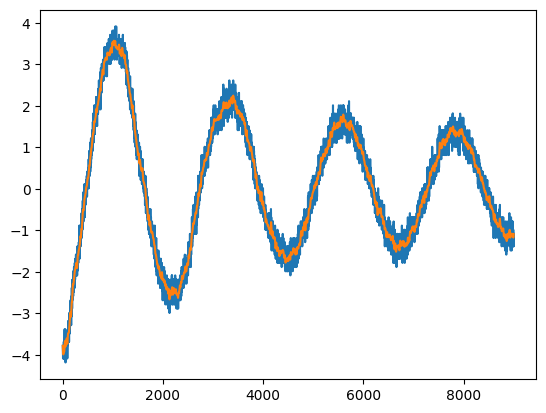

In [104]:
plt.plot(I)
plt.plot(I2)

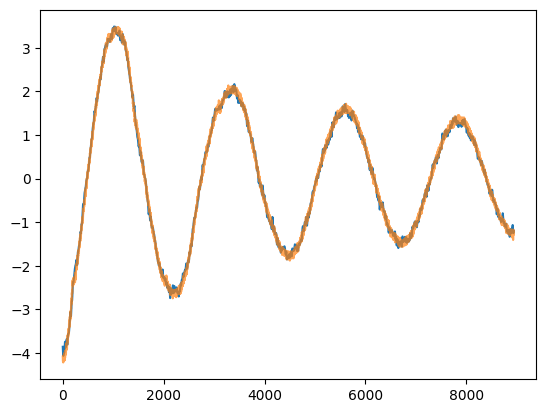

In [105]:
n=60
Ir = v/R
k=0.92
I22=I2[:-n]-0.08
Ir2 =  k*Ir[n:]
plt.plot(I22)
plt.plot(Ir2, alpha =0.7)

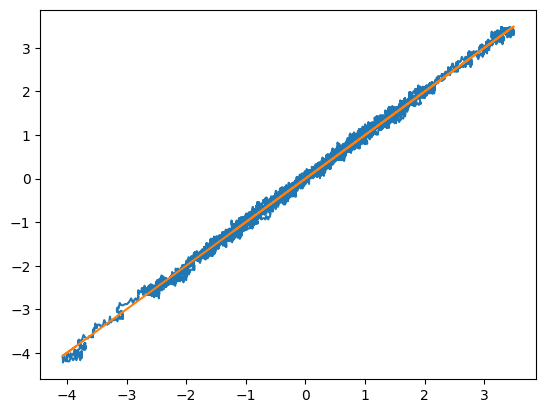

In [106]:
plt.plot( I22, Ir2)
plt.plot(I22,I22)

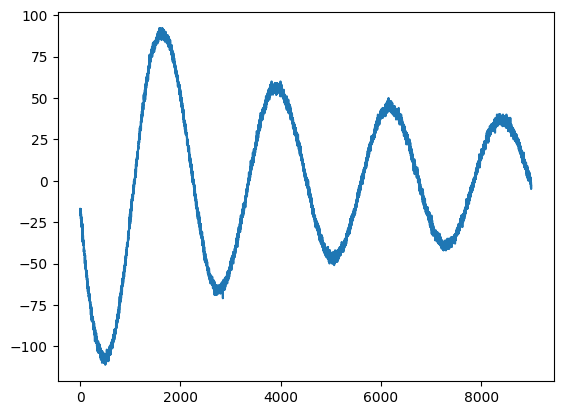

In [107]:
vc = df.CH1.values
vc = vc[1000:]
plt.plot(vc)

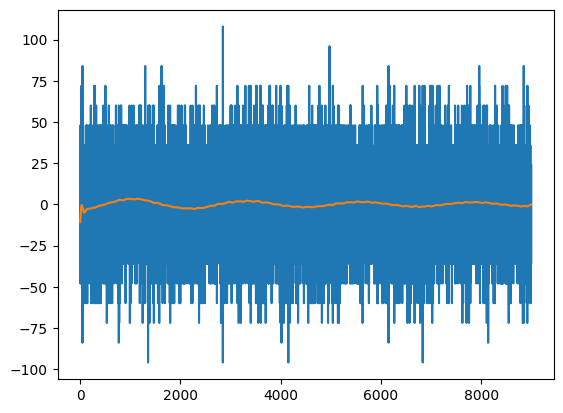

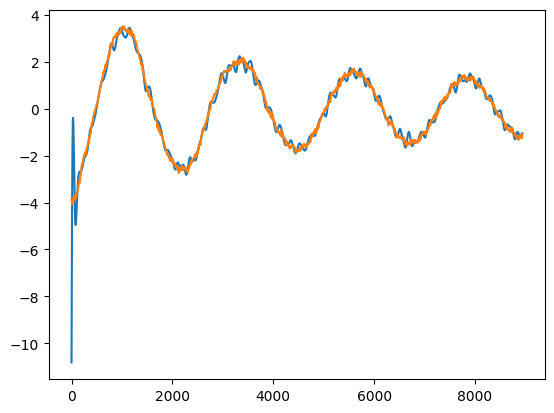

In [141]:
Cr = 120e-9
ic = Cr*np.diff(vc)/Ts
# i = c*dv/dt
plt.plot(ic)


fs = 1 / Ts          # sampling frequency
fc = 1e6          # cutoff frequency (Hz)
order = 4

# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')

# zero-phase filtering
ic2= signal.sosfiltfilt(sos, ic)
plt.plot(ic2)
plt.show()
#plt.plot(ic2)


#I22=I2[:-n]-0.08
ic22=ic2[:-n]
#Ir2 =  k*Ir[n:]
plt.plot(ic22)
plt.plot(I22)

#plt.plot(Ir2, alpha =0.7)

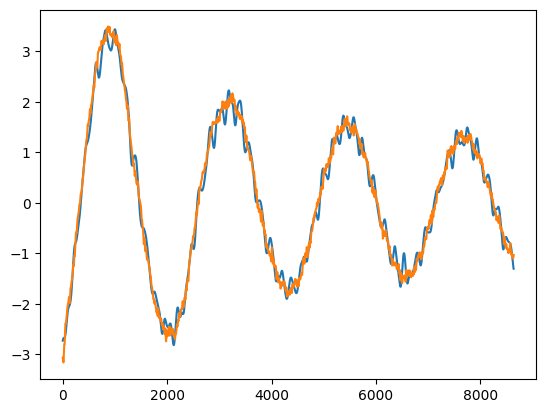

In [148]:
# no causal filter remove beg and end
nn=150
ic223 = ic22[nn:-nn]
I223=I22[nn:-nn]
plt.plot(ic223)
plt.plot(I223)

In [149]:
len(ic223), len(I223)

(8639, 8640)

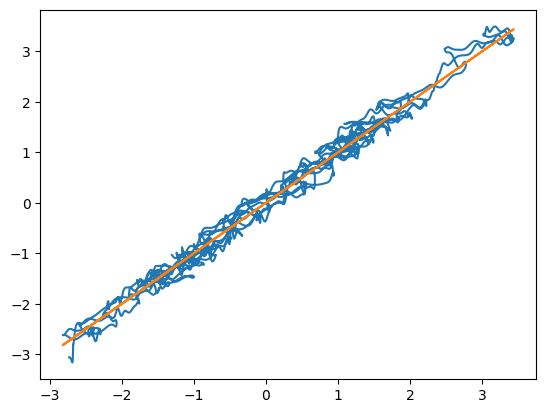

In [150]:
plt.plot(ic223, I223[1:])
plt.plot(ic223, ic223)

# Lm+Lr

# 45051.87173338579 0.8492077756084468 0.5887840577551897
Rcrit (Max to have res) 58.298308813013755
Fr =  44608.000103312224
m = 0.0514594687407179
f0 = 44608.00010331223
fd = 44548.898242978124


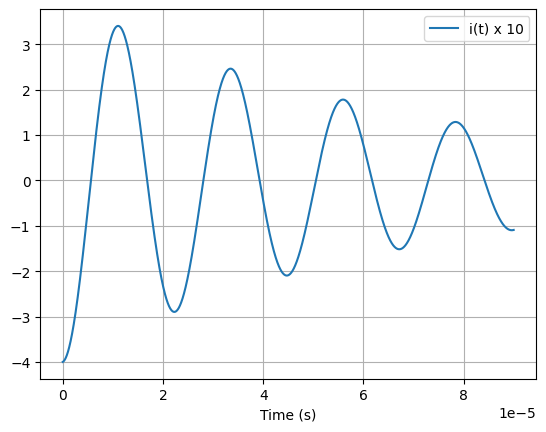

In [119]:
# RES

from math import *
L= 22e-6+82e-6
C=120e-9
F=1/(2*pi*sqrt(L*C))
R=50
m = (R/2)*sqrt(C/L)
Q=1/(2*m)
print("#", F, m, Q)
# 97953.09620956126 1.846372364689991 0.270801280154

import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

L = 22e-6+82e-6
C = 1.02*120e-9
Rcrit = 2*np.sqrt(L/C)
F=1/(2*pi*sqrt(L*C))
print("Rcrit (Max to have res)",Rcrit)
print("Fr = ", F)

R = 3  # <-- MUST be < 27 ohm
V0 = 48*3

w0 = 1/np.sqrt(L*C)
m = (R/2)*np.sqrt(C/L)

alpha = w0*m
wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

print("m =", m)
print("f0 =", w0/(2*np.pi))
print("fd =", wd/(2*np.pi))


def i(t, I0=10, phase = 0):
    return I0*np.exp(-alpha*t)*np.sin(wd*t-phase)



plt.figure()

plt.plot(time, i(time, I0=4, phase =pi/2), label="i(t) x 10")
#print("Max current A", i(t).max())
plt.xlabel("Time (s)")
plt.grid(True)
plt.legend()


#plt.plot(time, I2)
plt.show()


In [120]:
from utils import *
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

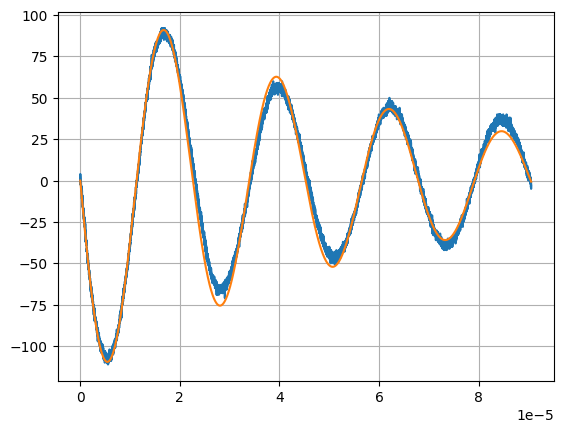

In [43]:
df = pd.read_csv("2026-01-12_17-47-35-714.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values 
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]



def dumpsin(t, Y0=10, phase = 0, L=104e-6,C=120e-9,R=3):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
vc2= dumpsin(time,  Y0=-120, phase = 0, L=(79+24.5)*1e-6,C=1.04*120e-9,R=3.4)


plt.plot(time, vc)
plt.plot(time, vc2)
plt.grid()


# Lr

In [151]:
V0=pd.read_csv("2026-01-12_17-39-34-446.csv").CH1.mean()
V145=pd.read_csv("2026-01-12_17-17-01-155.csv").CH1.mean() # 145.2
print(V0,V145)
kCH1=145.2/(V145-V0)
kCH1*V145-V0

-0.9615 146.9216


np.float64(145.21744486455856)

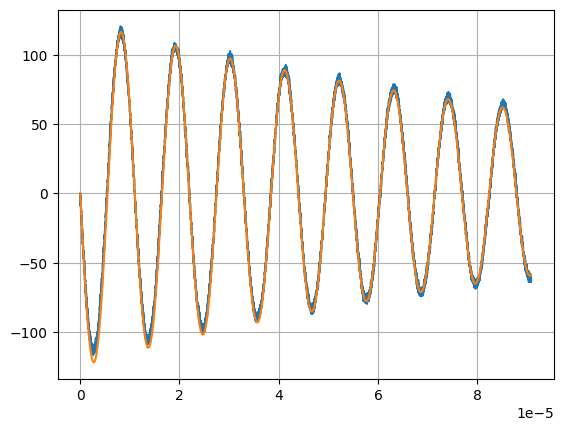

In [153]:
df = pd.read_csv("2026-01-12_17-30-26-003.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values 
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]



def dumpsin(t, Y0=10, phase = 0, L=104e-6,C=120e-9,R=3):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
vc2= dumpsin(time,  Y0=-125, phase = 0, L=(24.5)*1e-6,C=1.04*120e-9,R=0.4)


plt.plot(time, vc)
plt.plot(time, vc2)
plt.grid()


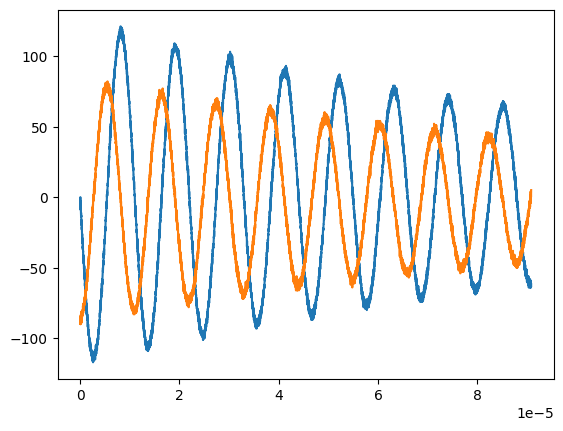

In [163]:
vc = df.CH1.values 
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]

ic = df.CH2.values 
ic= ic[idx:]




Ts= df.Ts.iloc[0]


t  =np.arange(0, len(vc)*Ts, Ts)
plt.plot(t,vc)
plt.plot(t,10*ic)

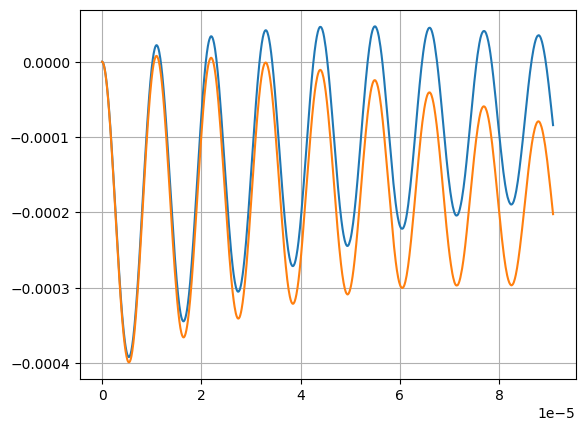

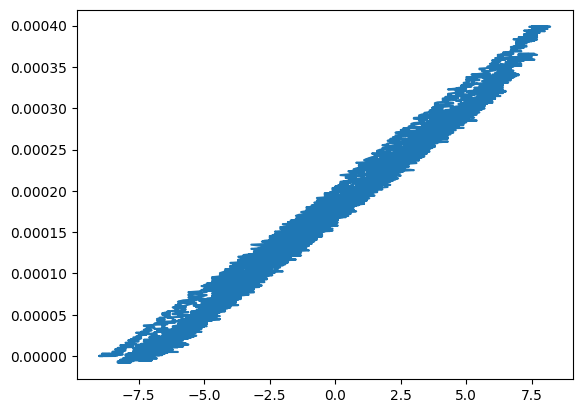

In [193]:
N=8
integ_v=Ts*np.cumsum(vc)
a=-13e-1
integ_v_corr= integ_v+a*t
# v = N*dflux/dt

plt.plot(t,integ_v)
plt.plot(t,integ_v_corr)
plt.grid()
plt.show()

plt.plot(ic,- integ_v_corr)

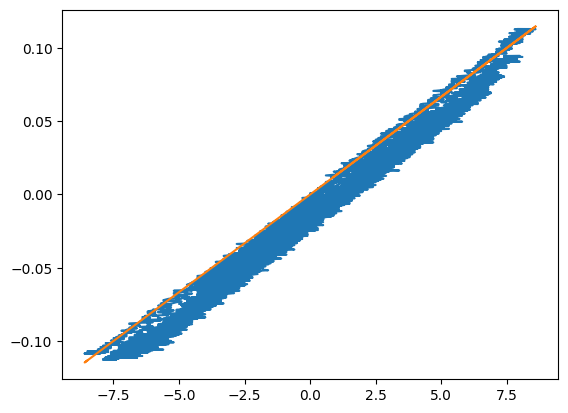

In [210]:
flux = integ_v_corr/N
# https://product.tdk.com/system/files/dam/doc/product/ferrite/ferrite/ferrite-core/data_sheet/80/db/fer/elp_43_10_28.pdf

Ae = 225e-6 # m2
B = flux /Ae
Ab=B.max()+B.min()
B=B-Ab/2

Ai=ic.max()+ic.min()
ic2=ic-Ai/2
plt.plot(ic2,- B)

#N*flux = L * i 
L=24e-6
plt.plot(ic2,L*ic2/(N*Ae))

# Lm

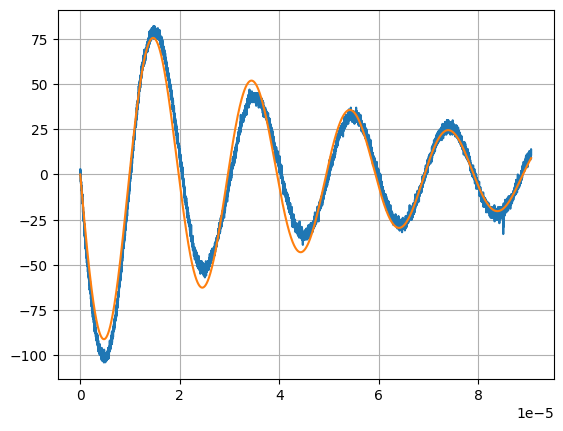

In [46]:
df = pd.read_csv("2026-01-12_17-37-55-165.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values 
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]



def dumpsin(t, Y0=10, phase = 0, L=104e-6,C=120e-9,R=3):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
vc2= dumpsin(time,  Y0=-100, phase = 0, L=(79)*1e-6,C=1.04*120e-9,R=3)


plt.plot(time, vc)
plt.plot(time, vc2)
plt.grid()


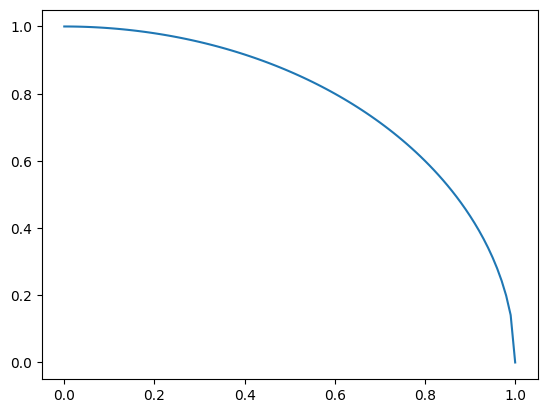

In [47]:
#wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency
#Gw=wd/w0=np.sqrt(1 - m*m) 

m= np.arange(0,1.01,0.01)
Gw=np.sqrt(1 - m*m) 
plt.plot(m, Gw)

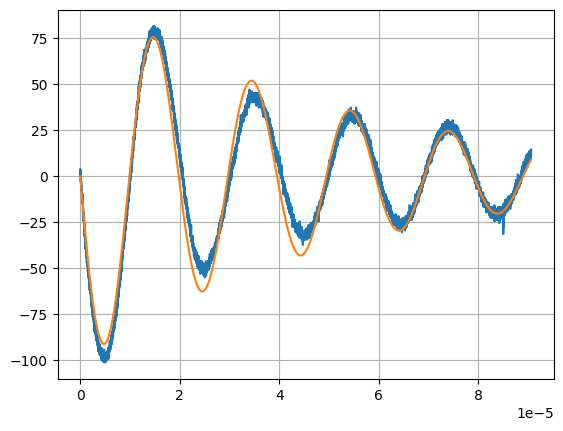

In [48]:
plt.plot(time, kCH1*vc-V0)
plt.plot(time, vc2)
plt.grid()



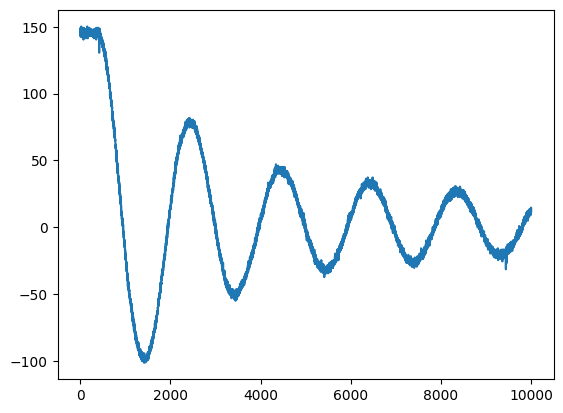

In [49]:
df = pd.read_csv("2026-01-12_17-37-55-165.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values 
#idx= trigger(vc, transition='fall', thresh=0)[0]

#vc= vc[idx:]

vc=kCH1*vc-V0
plt.plot( vc)

In [50]:
vc[:100].mean()

np.float64(145.44170091545277)

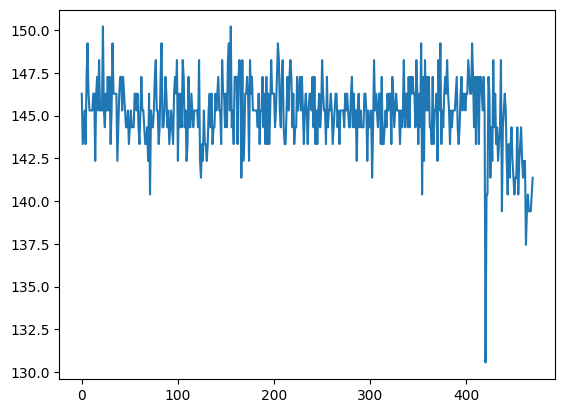

In [51]:
plt.plot(vc[:500-30])

In [52]:
i=np.where(vc[:500-30] < 132)[0][0]
i

np.int64(420)

In [53]:
np.sin(pi/2)

np.float64(1.0)

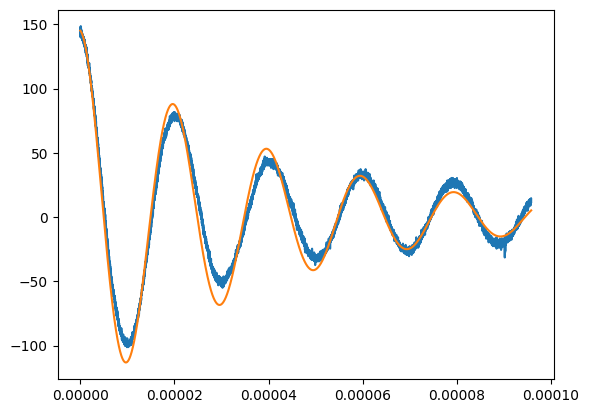

In [54]:
vc2=vc[i+1:]
t= np.arange(0,len(vc2)*Ts,Ts)
plt.plot(t,vc2)

vcth2= dumpsin(t,  Y0=145, phase = -pi/2, L=(79)*1e-6,C=1.05*120e-9,R=4)
plt.plot(t,vcth2)

Modèles physiques acceptés (classiques)

Pertes par hystérésis

**Modèle de Steinmetz (simplifié) :**

$$
P_h = k_h \, f \, B_{\text{max}}^{\,n} \, V
$$

avec :

- $n \approx 1.6 \sim 2.2$ (selon le matériau)
- pertes proportionnelles à la fréquence $f$
- pertes proportionnelles au volume $V$


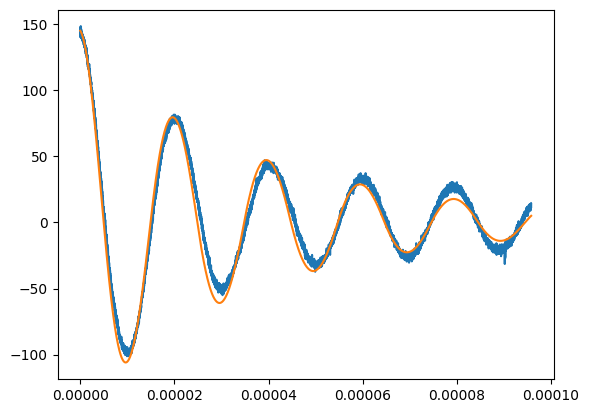

In [55]:
def dumpsin2(t, Y0=10, phase = 0, L=104e-6,C=120e-9,R=3, k =0.01):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency
    arr=np.zeros(len(t))
    arr[0]=Y0
    for i in range(1,len(t)):
        Rv=(R+k*abs(arr[i-1]))
        m = (Rv/2)*np.sqrt(C/L)
        alpha = w0*m
        wd = w0*np.sqrt(1 - m*m) 
        arr[i]= Y0*np.exp(-alpha*t[i])*np.sin(wd*t[i]-phase)
    return arr
plt.plot(t,vc2)

vcth2= dumpsin2(t,  Y0=145, phase = -pi/2, L=(79)*1e-6,C=1.05*120e-9,R=4, k=0.01)
plt.plot(t,vcth2)

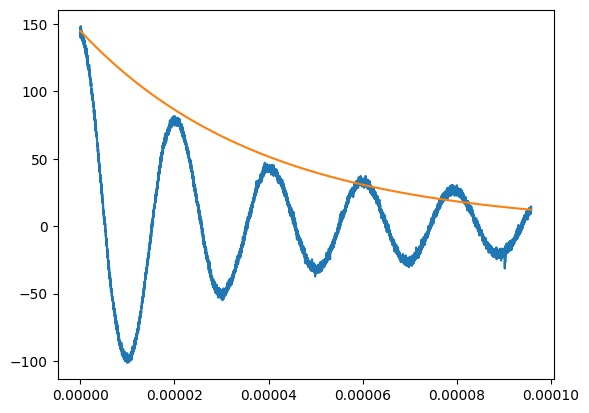

In [56]:
def dumpsin2(t, Y0=10, phase=0, L=104e-6, C=120e-9, R=3, k=0.01):
    import numpy as np

    w0 = 1 / np.sqrt(L * C)
    arr = np.zeros(len(t))
    arr[0] = Y0

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]

        # amplitude-dependent damping (hysteresis-like)
        Rv = R + k * abs(arr[i-1])

        m = (Rv / 2) * np.sqrt(C / L)
        if m >= 1:
            break

        alpha = w0 * m
        wd = w0 * np.sqrt(1 - m*m)

        # incremental evolution (THIS is the critical fix)
        arr[i] = (
            arr[i-1]
            * np.exp(-alpha * dt)
            * np.cos(wd * dt)
        )

    return arr
plt.plot(t,vc2)

vcth2= dumpsin2(t,  Y0=145, phase = -pi/2, L=(79)*1e-6,C=1.05*120e-9,R=4, k=0.00000001)
plt.plot(t,vcth2)

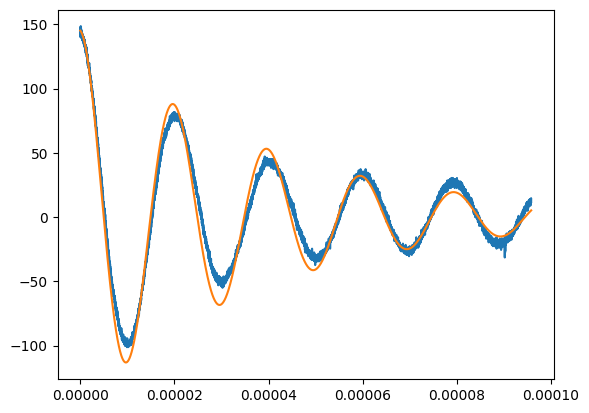

In [57]:
def dumpsin2(t, Y0=10, phase=0, L=104e-6, C=120e-9, R=3, k=0.01):
    import numpy as np

    w0 = 1 / np.sqrt(L * C)

    x = np.zeros(len(t))   # main signal
    y = np.zeros(len(t))   # quadrature (90° shifted)

    x[0] = Y0 * np.sin(phase)
    y[0] = Y0 * np.cos(phase)

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]

        # amplitude-dependent damping (hysteresis-like)
        A = np.sqrt(x[i-1]**2 + y[i-1]**2)
        Rv = R + k * A

        m = (Rv / 2) * np.sqrt(C / L)
        if m >= 1:
            break

        alpha = w0 * m
        wd = w0 * np.sqrt(1 - m*m)

        e = np.exp(-alpha * dt)
        c = np.cos(wd * dt)
        s = np.sin(wd * dt)

        # rotation + decay (THIS is the key)
        x[i] = e * ( x[i-1]*c + y[i-1]*s )
        y[i] = e * ( y[i-1]*c - x[i-1]*s )

    return x
plt.plot(t,vc2)

vcth2= dumpsin2(t,  Y0=145, phase = pi/2, L=(79)*1e-6,C=1.05*120e-9,R=4, k=0.00000001)
plt.plot(t,vcth2)

# TRANS VS NO TRANS

### FILTER 

In [37]:
import numpy as np
import matplotlib.pyplot as plt

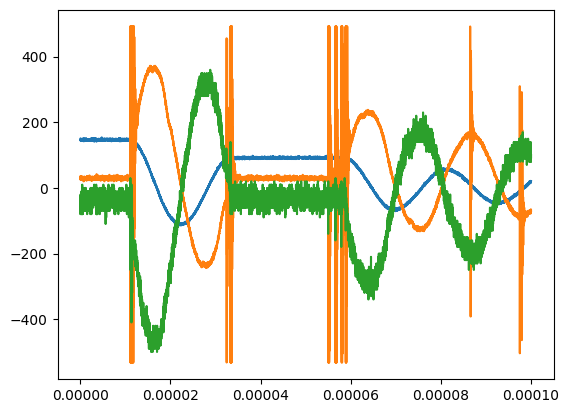

In [45]:
df = pd.read_csv("2026-01-17_17-12-54-609.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values 
I = df.CH2.values
vr= -df.CH3.values
t =np.arange(0, len(vc)*Ts, Ts)
plt.plot(t, vc)
plt.plot(t, vr*1e4)
plt.plot(t, I*100)

In [50]:
import numpy as np
from scipy import signal

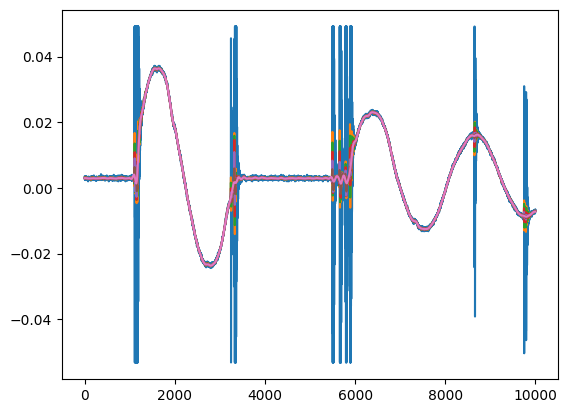

In [54]:
plt.plot(vr)
for fc in np.arange(1e6,12e6,2e6)[::-1]:
    fs = 1 / Ts          # sampling frequency
    #fc = 2e6          # cutoff frequency (Hz)
    order = 4
    
    # design filter
    sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
    
    # zero-phase filtering
    vr2= signal.sosfiltfilt(sos, vr)
    
    plt.plot(vr2)

(5400.0, 6200.0)

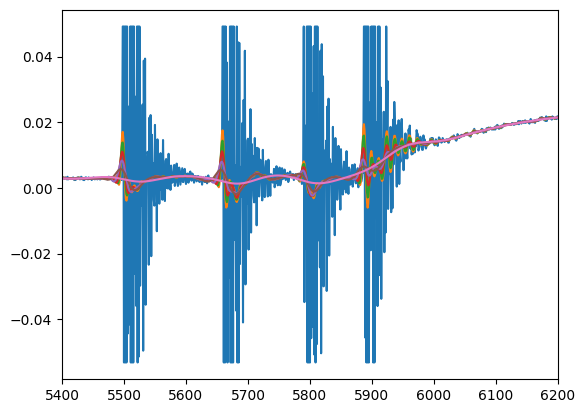

In [57]:
plt.plot(vr)
for fc in np.arange(1e6,12e6,2e6)[::-1]:
    fs = 1 / Ts          # sampling frequency
    #fc = 2e6          # cutoff frequency (Hz)
    order = 4
    
    # design filter
    sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')
    
    # zero-phase filtering
    vr2= signal.sosfiltfilt(sos, vr)
    
    plt.plot(vr2)
plt.xlim([5400,6200])

# END